In [1]:
from Utils.import_packages import *

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV

from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

import string
import swifter


# Download NLTK data
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
# nltk.download('punkt_tab')
# nltk.download('averaged_perceptron_tagger_eng')

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

warnings.filterwarnings('ignore')


[nltk_data] Error loading averaged_perceptron_tagger: <urlopen error
[nltk_data]     [Errno 11001] getaddrinfo failed>
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ethelda\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Ethelda\AppData\R

In [50]:
train = pd.read_csv('Data/train_labelled3.csv')
val = pd.read_csv('Data/val_labelled3.csv')
test = pd.read_csv('Data/test_labelled3.csv')

In [9]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
    
# Preprocessing function
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    
    # Tokenize text
    tokens = word_tokenize(text.lower(), language='english')
    
    # Get POS tags
    pos_tags = pos_tag(tokens)

    # Remove punctuation and stopwords, and lemmatize
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags 
              if word not in stop_words and word not in string.punctuation]
    return ' '.join(tokens)

def text_to_vector(df, vectorise_columns, numerical_columns = []):
    vectorizer = CountVectorizer()
    ret_df = pd.DataFrame()
    all_col = vectorise_columns + numerical_columns
    for col in all_col:
        if col in vectorise_columns:
            vectorized = vectorizer.fit_transform(df[col])
            ret_df = pd.concat([ret_df, pd.DataFrame(vectorized.toarray())], axis=1)
        else:
            ret_df[col] = df[col]
    return ret_df


In [51]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

train = train.reset_index(drop=True)
val = val.reset_index(drop=True)
test = test.reset_index(drop=True)

ind = []
for i, s in enumerate(train["title"].tolist()):
    scores = analyzer.polarity_scores(s)
    if scores["neu"] == max(scores["neg"], scores["neu"], scores["pos"]):
        ind += [i]
train = train.drop(index=ind)
print(train.shape)

ind = []
for i, s in enumerate(val["title"].tolist()):
    scores = analyzer.polarity_scores(s)
    if scores["neu"] == max(scores["neg"], scores["neu"], scores["pos"]):
        ind += [i]
val = val.drop(index=ind)
print(val.shape)

ind = []
for i, s in enumerate(test["title"].tolist()):
    scores = analyzer.polarity_scores(s)
    if scores["neu"] == max(scores["neg"], scores["neu"], scores["pos"]):
        ind += [i]

test = test.drop(index=ind)
print(test.shape)

(737, 9)
(134, 9)
(390, 9)


In [52]:
train['processed_title'] = train['title'].swifter.apply(preprocess_text)
val['processed_title'] = val['title'].swifter.apply(preprocess_text)
test['processed_title'] = test['title'].swifter.apply(preprocess_text)

Pandas Apply:   0%|          | 0/737 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/134 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/390 [00:00<?, ?it/s]

# Naive Bayes

In [53]:

# Prepare data for Naive Bayes
X_train = train['processed_title']
y_train  = train['sentiment_label']

X_val = val['processed_title']
y_val  = val['sentiment_label']

# Convert text to numerical features using CountVectorizer
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_val_vectorized = vectorizer.transform(X_val)

# Train a Naive Bayes classifier
nb = MultinomialNB()
nb.fit(X_train_vectorized, y_train)

# Make predictions
y_pred_val = nb.predict(X_val_vectorized)

# Evaluate the model
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report:\n", classification_report(y_val, y_pred_val))

Accuracy: 0.5373134328358209
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.38      0.45        65
           1       0.54      0.68      0.60        69

    accuracy                           0.54       134
   macro avg       0.54      0.53      0.52       134
weighted avg       0.54      0.54      0.53       134



In [54]:
preds_NB = nb.predict_proba(X_val_vectorized)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, preds_NB)  
roc_auc_NB = auc(fpr, tpr)
roc_auc_NB

0.5156075808249722

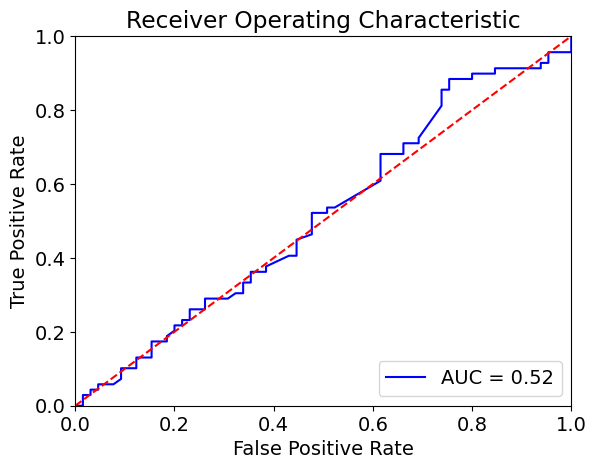

In [55]:
import matplotlib.pyplot as plt
plt.rc("font", size=14)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc_NB)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [56]:

train_val = pd.concat([train, val])

# Prepare data for Naive Bayes
X_train_val = train_val['processed_title']
y_train_val  = train_val['sentiment_label']

X_test = test['processed_title']
y_test  = test['sentiment_label']

# Convert text to numerical features using CountVectorizer
vectorizer = CountVectorizer()
X_train_val_vectorized = vectorizer.fit_transform(X_train_val)
X_test_vectorized = vectorizer.transform(X_test)

# Train a Naive Bayes classifier
nb = MultinomialNB()
nb.fit(X_train_val_vectorized, y_train_val)

# Make predictions
y_pred = nb.predict(X_test_vectorized)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6051282051282051
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.64      0.68       255
           1       0.44      0.55      0.49       135

    accuracy                           0.61       390
   macro avg       0.58      0.59      0.58       390
weighted avg       0.63      0.61      0.61       390



In [65]:
test["pred_prob_0"] = [i[0] for i in nb.predict_proba(X_test_vectorized)]
test["pred"] = y_pred

del test["pred_prob"]
test

,title,source,topic,ticker,company name(s) - cleaned,date,sentiment_label,bert_sentiment_score,bert_sentiment_prob,processed_title,pred,pred_prob_0
275,Apple honors 2024 App Store Award winners - Ap...,https://news.google.com/rss/articles/CBMiiAFBV...,NaN,AAPL,NaN,2024-12-11,0,1,0.994484,apple honor 2024 app store award winner apple ...,1,0.182822
302,Apple shares target increased on strong execut...,https://news.google.com/rss/articles/CBMirgFBV...,NaN,AAPL,NaN,2024-12-13,0,1,0.998181,apple share target increase strong execution i...,0,0.513031
642,Abbott Laboratories Enters into Five Year Cred...,SEC Form 8k,Health Care Equipment,ABT,Abbott Laboratories,2024-01-29,1,0,0.938600,abbott laboratories enters five year credit ag...,1,0.000203
986,Accenture Acquires True North Solutions to Hel...,https://news.google.com/rss/articles/CBMi1gFBV...,NaN,ACN,NaN,2024-07-09,0,1,0.995533,accenture acquire true north solution help cli...,0,0.969342
1067,Accenture plc (NYSE:ACN) acquired Award Soluti...,Capital IQ Transaction Database,Accenture plc (NYSE:ACN) (IT Consulting and Ot...,ACN,Accenture plc,2024-11-21,0,0,0.609164,accenture plc nyse acn acquire award solution inc,0,0.959854
...,...,...,...,...,...,...,...,...,...,...,...,...
60019,Does the Fed s Lowering the Interest Rates Str...,https://mises.org/podcasts/audio-mises-wire/do...,economics,WAB,NaN,2024-12-03,1,1,0.999063,fed lower interest rate strengthen economic gr...,0,0.891561
60499,WEC Energy Group Reports Strong Growth and Fut...,https://news.google.com/rss/articles/CBMiqwFBV...,NaN,WEC,NaN,2024-12-06,1,1,0.998985,wec energy group report strong growth future p...,1,0.380353
60612,Wells Fargo & Company Approves and Adopts the ...,SEC Form 8k,Diversified Banks,WFC,Wells Fargo & Company,2024-01-24,1,1,0.996534,well fargo company approve adopt by-laws,1,0.461665
61338,West Pharma Wins Behavioral Safety Award at 20...,https://news.google.com/rss/articles/CBMiggFBV...,NaN,WST,NaN,2024-09-26,0,1,0.996326,west pharma win behavioral safety award 2024 p...,0,0.712891


In [67]:
test.to_csv('results/naive_bayes_results.csv', index=False)

# Logistic Regression

In [57]:
param_grid = {'C': [0.01, 0.1, 0.5], 'solver': ['lbfgs', 'liblinear']}
logreg = LogisticRegression(solver = 'lbfgs', penalty = 'l2', C = 0.1, warm_start=True, random_state=2024)

grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring="f1")
grid_search.fit(X_train_vectorized, y_train)

logreg = LogisticRegression(**grid_search.best_params_, warm_start=True, random_state=2024)
logreg.fit(X_train_vectorized, y_train)

# Make predictions
y_pred_val = logreg.predict(X_val_vectorized)
# Evaluate the model
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report:\n", classification_report(y_val, y_pred_val))

Accuracy: 0.4925373134328358
Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.40      0.43        65
           1       0.51      0.58      0.54        69

    accuracy                           0.49       134
   macro avg       0.49      0.49      0.49       134
weighted avg       0.49      0.49      0.49       134



In [58]:
preds_lr = logreg.predict_proba(X_val_vectorized)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, preds_NB)  
roc_auc_lr = auc(fpr, tpr)
roc_auc_lr

0.5156075808249722

# RandomForest Classifier

In [13]:
rf = RandomForestClassifier(random_state=2024) 
rf.fit(X_train_vectorized, y_train)

# Make predictions
y_pred_val = rf.predict(X_val_vectorized)
# Evaluate the model
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report:\n", classification_report(y_val, y_pred_val))

Accuracy: 0.5154950869236583
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.45      0.49       672
           1       0.51      0.58      0.54       651

    accuracy                           0.52      1323
   macro avg       0.52      0.52      0.51      1323
weighted avg       0.52      0.52      0.51      1323



In [14]:
preds_rf = rf.predict_proba(X_val_vectorized)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, preds_NB)  
roc_auc_rf = auc(fpr, tpr)
roc_auc_rf

0.5401237107746325